## Import Library

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, sum as spark_sum

!pip install catboost
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, accuracy_score,
    roc_auc_score, confusion_matrix,
    f1_score, precision_score, recall_score
)

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


## Mulai Spark Session

In [ ]:
spark = (
    SparkSession.builder  # untuk buka 'builder' buat pengaturan sesi Spark
    .appName("BigData_Analytics")  # nama aplikasi yang akan ditampilkan di UI Spark
    .config("spark.sql.shuffle.partitions", "50") # mengatur jumlah partisi shuffle menjadi 50
    .getOrCreate() #untuk mulai sesi
)

## Load Dataset

In [ ]:
file = "/content/df_clean.parquet"

df = spark.read.parquet(file)

## Descriptive Analytics

In [ ]:
print("\nSchema:")
df.printSchema()



Schema:
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- delivery_time: integer (nullable = true)
 |-- is_late: integer (nullable = true)
 |-- customer_state: string (nullable = true)
 |-- customer_city: string (nullable = true)
 |-- is_satisfied: integer (nullable = true)
 |-- total_payment_value: double (nullable = true)
 |-- total_items: long (nullable = true)
 |-- total_price: double (nullable = true)
 |-- total_freight: double (nullable = true)



In [ ]:
print(f"\nTotal rows : {df.count():,}")
print(f"Columns    : {len(df.columns)}")


Total rows : 95,830
Columns    : 11


In [ ]:
df.show(5, truncate=False)

+--------------------------------+--------------------------------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|order_id                        |customer_id                     |delivery_time|is_late|customer_state|customer_city|is_satisfied|total_payment_value|total_items|total_price|total_freight|
+--------------------------------+--------------------------------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|615ae1b88a25a4ac47fbf55c9c847b6e|25daddfce277eafad87c4d28d71d8229|10           |0      |PR            |londrina     |0           |84.64              |1          |64.99      |19.65        |
|4d2d8a4224215f680cc5221011347401|5957d9ae822bcbe88c00fb8286362339|35           |1      |RS            |rio grande   |1           |132.57             |1          |117.0      |15.57        |
|12c35cf2a5171b0fb8e19d60abcb9353|96d3fe655ac136a3

In [ ]:
df.describe().show()

+-------+--------------------+--------------------+------------------+-------------------+--------------+-------------------+------------------+-------------------+------------------+------------------+------------------+
|summary|            order_id|         customer_id|     delivery_time|            is_late|customer_state|      customer_city|      is_satisfied|total_payment_value|       total_items|       total_price|     total_freight|
+-------+--------------------+--------------------+------------------+-------------------+--------------+-------------------+------------------+-------------------+------------------+------------------+------------------+
|  count|               95830|               95830|             95830|              95830|         95830|              95830|             95830|              95830|             95830|             95830|             95830|
|   mean|                NULL|                NULL|12.455838463946572|0.07995408535949076|          NULL|       

## Exploratory Data Analysis

In [ ]:
# untuk cek null value
print("\nNull Value Check:")
null_counts = df.select(
    [spark_sum(col(c).isNull().cast("int")).alias(c) for c in df.columns]
)
null_counts.show()


Null Value Check:
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|order_id|customer_id|delivery_time|is_late|customer_state|customer_city|is_satisfied|total_payment_value|total_items|total_price|total_freight|
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+
|       0|          0|            0|      0|             0|            0|           0|                  0|          0|          0|            0|
+--------+-----------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+



In [ ]:
# untuk cek kelas imbalance
print("\nTarget Class Distribution:")
df.groupBy("is_satisfied") \
  .count() \
  .withColumnRenamed("count", "total") \
  .orderBy("is_satisfied") \
  .show()


Target Class Distribution:
+------------+-----+
|is_satisfied|total|
+------------+-----+
|           0|20130|
|           1|75700|
+------------+-----+



## Feature Engineering

### Strategi Feature Engineering:
### 1. Rasio dasar: price per item, freight ratio, payment diff
### 2. Log Transform untuk mengurangi efek outlier pada kolom numerik besar
### 3. Interaksi fitur kategorikal: menggabungkan customer_state & customer_city

### CatBoost tidak pakai StringIndexer atau VectorAssembler karena udah bisa menangani fitur kategorikal (string) secara native.

In [ ]:
## FEATURE ENGINEERING
# konversi ke Pandas
pdf = df.toPandas() #soalnya catboost ga bisa spark


## NUMERICAL FEATURE ENGINEERING
# buat fitur baru harga per item untuk nambah info
pdf['price_per_item'] = (
    pdf['total_price'] / (pdf['total_items'] + 1e-6)  # 1e-6 mencegah division by zero biar kalo ada data mendekati 0 pembagiannya ga error
)


##  LOG TRANSFORMATION
# Log dibuat untuk total_payment_value dan total_price (nanti kolom asli di-drop di step selanjutnya)
# tujuan kedua itu dijadikan log biar outlier transaksi jaraknya ga terlalu jauh dari mayoritas
for c in [
    'total_payment_value',C
    'total_price',
]:
    pdf[f'{c}_log'] = np.log1p(pdf[c])


##  CATEGORICAL FEATURE INTERACTION
#tujuannya mempermudah tugas model untuk mempelajari pola perilaku konsumen berdasarkan kombinasi wilayahnya
pdf['state_city_combo'] = (
    pdf['customer_state'].astype(str)
    + '_'
    + pdf['customer_city'].astype(str)
)

##  CATEGORICAL COLUMNS
cat_cols = [
    'customer_state',
    'customer_city',
    'state_city_combo'
]

for c in cat_cols:
    pdf[c] = pdf[c].astype(str) #untuk encoding mastiin tipe data bener string


## OUTPUT INFO
print(f"Shape setelah feature engineering : {pdf.shape}")

print("\nFitur yang digunakan (termasuk kolom asli total_freight):")
print([
    'price_per_item',
    'total_freight',          # ini fitur asli yang langsung masuk model
    'total_payment_value_log',
    'total_price_log',
    'state_city_combo'
])


Shape setelah feature engineering : (95830, 15)

Fitur yang digunakan (termasuk kolom asli total_freight):
['price_per_item', 'total_freight', 'total_payment_value_log', 'total_price_log', 'state_city_combo']


## Persiapan Data: Split Train & Test

In [ ]:
## TRAIN TEST SPLIT

from sklearn.model_selection import train_test_split

target_col = 'is_satisfied'

#ini drop target prediksi sama fitur yang ga penting untuk model + drop fitur yg udh digantiin log
drop_cols = [
    c for c in [
        'order_id',
        'customer_id',
        target_col,
        'total_payment_value',  # digantikan _log
        'total_price',          # digantikan _log
    ]
    if c in pdf.columns
]

X = pdf.drop(columns=drop_cols)
y = pdf[target_col]


## TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, #train 80% dan test 20%
    stratify=y, #pastiin proporsi label target pada y_train dan y_test sama persis dengan proporsi pada data asli (y).
    random_state=42 #untuk reproducible
)

##  OUTPUT INFO

print(f"Training set : {X_train.shape[0]:,} rows")
print(f"Test set     : {X_test.shape[0]:,} rows")
print(f"\nFitur total  : {X_train.shape[1]} kolom")
print("Kolom fitur  :", X_train.columns.tolist())


Training set : 76,664 rows
Test set     : 19,166 rows

Fitur total  : 10 kolom
Kolom fitur  : ['delivery_time', 'is_late', 'customer_state', 'customer_city', 'total_items', 'total_freight', 'price_per_item', 'total_payment_value_log', 'total_price_log', 'state_city_combo']


In [ ]:
print(X.columns.tolist())

['delivery_time', 'is_late', 'customer_state', 'customer_city', 'total_items', 'total_freight', 'price_per_item', 'total_payment_value_log', 'total_price_log', 'state_city_combo']


## Handling Class Imbalance: Class Weighting



In [ ]:
# CatBoost menggunakan auto_class_weights="Balanced" pada model, sehingga bobot kelas dihitung otomatis oleh library
# Kalkulasi manual weight_0 / weight_1 di bawah hanya untuk referensi informatif weight idealnya brp (ini ga dipake di model)

class_counts = y_train.value_counts()

# Ini info tambahan saja — auto_class_weights="Balanced" sudah menghitungnya
weight_0_ref = class_counts[1] / class_counts[0]
weight_1_ref = 1.0

print("\nClass Distribution (Training Set)")
print(class_counts)

print("\nClass Weight Reference (auto, tidak dioper manual ke model)")
print(f"Class 0 weight (ref) : {weight_0_ref:.4f}")
print(f"Class 1 weight (ref) : {weight_1_ref:.4f}")



Class Distribution (Training Set)
is_satisfied
1    60560
0    16104
Name: count, dtype: int64

Class Weight Reference (auto, tidak dioper manual ke model)
Class 0 weight (ref) : 3.7606
Class 1 weight (ref) : 1.0000


## 10-Fold Stratified Cross Validation

### Tujuan Cross Validation:
### Mengukur stabilitas dan generalisasi model secara lebih robust dibanding single train-test split.
### `StratifiedKFold` digunakan agar proporsi kelas target tetap terjaga di setiap fold.
### Setiap fold melatih model dari awal dengan hyperparameter yang sama dan mencatat metrik evaluasi.
### Hasil akhir: rata-rata ± standar deviasi dari 10 fold — cerminan performa model yang lebih andal.


In [ ]:
N_FOLDS = 10

skf = StratifiedKFold(
    n_splits=N_FOLDS, #proses latihan bakal diulang 10x
    shuffle=True,
    random_state=42
)

#wadah kosong berupa list untuk menampung riwayat performa model dari ke-10 fold tersebut
cv_scores = []
all_oof_preds = []
all_oof_targets = []
best_iterations = []
fold = 1

#proses looping tiap fold
for train_idx, val_idx in skf.split(X_train, y_train): #tiap loop, skf.split akan kasi daftar indeks baris mana saja yang masuk ke data latihan (train_idx) dan data validasi (val_idx)

    print(f"\n========== Fold {fold} ==========")
    #memotong dataset X_train dan y_train asli menjadi potongan kecil khusus untuk fold yang sedang berjalan saat itu
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]

    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    train_pool = Pool( # ini memproses kolom categorical secara otomatis di balik layar
        X_tr,
        y_tr,
        cat_features=cat_cols
    )

    val_pool = Pool( # ini memproses kolom categorical secara otomatis di balik layar
        X_val,
        y_val,
        cat_features=cat_cols
    )

    cb_model = CatBoostClassifier(
        iterations=2000, #jumlah iterasi pelatihan
        learning_rate=0.03, #makin kecil makin detail model bljr
        depth=8, #kedalaman maks tiap pohon keputusan
        eval_metric='AUC', #indikator utama yang dipakai model untuk menilai dirinya sendiri
        auto_class_weights='Balanced', # otomatis menangani class imbalance
        l2_leaf_reg=5, #regularisasi untuk mencegah overfit
        random_seed=42,
        task_type='CPU',
        early_stopping_rounds=100, #Jika dalam 100 iterasi berturut-turut skor AUC pada data validasi tidak mengalami kenaikan,model berhenti belajar otomatis
        verbose=100
    )

    cb_model.fit(
        train_pool,
        eval_set=val_pool
    )

    val_probs = cb_model.predict_proba(val_pool)[:, 1] #mengeluarkan prediksi dalam bentuk probabilitas/persentase
    val_preds = (val_probs >= 0.5).astype(int) #jika peluangnya di atas atau sama dengan 50% (0.5) dikategorikan sebagai 1. Jika di bawah itu,maka 0.

    all_oof_preds.append(val_probs)
    all_oof_targets.append(y_val)
    best_iterations.append(cb_model.get_best_iteration()) # simpen best iteration

    fold_auc = roc_auc_score(
        y_val,
        val_probs
    )
    #menghitung 5 metrik evaluasi sekaligus untuk fold tersebut
    fold_accuracy = accuracy_score(y_val, val_preds)
    fold_f1 = f1_score(y_val, val_preds, average='weighted')
    fold_precision = precision_score(y_val, val_preds, average='weighted')
    fold_recall = recall_score(y_val, val_preds, average='weighted')

    cv_scores.append({
        'fold': fold,
        'auc': fold_auc,
        'accuracy': fold_accuracy,
        'f1_score': fold_f1,
        'precision': fold_precision,
        'recall': fold_recall
    })

    fold += 1

cv_df = pd.DataFrame(cv_scores)

print("\n==============================")
print("10-FOLD CV RESULT")
print("==============================")
print(cv_df)



========== Fold 1 ==========
0:	test: 0.6748637	best: 0.6748637 (0)	total: 180ms	remaining: 6m
100:	test: 0.7037864	best: 0.7039432 (97)	total: 12.9s	remaining: 4m 2s
200:	test: 0.7048759	best: 0.7048759 (200)	total: 24.3s	remaining: 3m 37s
300:	test: 0.7055070	best: 0.7055070 (300)	total: 36.2s	remaining: 3m 24s
400:	test: 0.7059961	best: 0.7060468 (399)	total: 48.4s	remaining: 3m 13s
500:	test: 0.7060880	best: 0.7062461 (434)	total: 1m 3s	remaining: 3m 8s
600:	test: 0.7068649	best: 0.7068649 (600)	total: 1m 17s	remaining: 2m 59s
700:	test: 0.7068633	best: 0.7070932 (682)	total: 1m 31s	remaining: 2m 50s
800:	test: 0.7074682	best: 0.7074682 (800)	total: 1m 46s	remaining: 2m 38s
900:	test: 0.7072081	best: 0.7077027 (838)	total: 2m	remaining: 2m 27s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7077026585
bestIteration = 838

Shrink model to first 839 iterations.

========== Fold 2 ==========
0:	test: 0.6627247	best: 0.6627247 (0)	total: 145ms	remaining: 4m 49s
10

In [ ]:
##  CV RESULT SUMMARY

print("\nCross Validation Results per Fold:")
print(cv_df.to_string(index=False))
print(f"\nMean AUC      : {cv_df['auc'].mean():.4f} +/- {cv_df['auc'].std():.4f}")
print(f"Mean Accuracy : {cv_df['accuracy'].mean():.4f} +/- {cv_df['accuracy'].std():.4f}")
print(f"Mean F1-Score : {cv_df['f1_score'].mean():.4f} +/- {cv_df['f1_score'].std():.4f}")

##  THRESHOLD TUNING MENGGUNAKAN OOF PREDICTIONS

#gabungin hasil prediksi 10 fold dari hasil tebakan dan nilai target asli
oof_preds_combined   = np.concatenate(all_oof_preds)
oof_targets_combined = np.concatenate(all_oof_targets)

#Proses Pencarian Batasan Terbaik
best_f1           = 0
best_f1_threshold = 0.5

# Simpan semua pasangan threshold-f1 untuk visualisasi
thresholds = []
f1_scores  = []

for thresh in np.arange(0.01, 0.99, 0.01):
    oof_predictions = (oof_preds_combined >= thresh).astype(int) #data probabilitas diubah secara paksa menjadi angka 0 atau 1 berdasarkan angka threshold simulasi saat itu (thresh).
    f1_bin = f1_score(oof_targets_combined, oof_predictions, average="binary")
    thresholds.append(thresh)
    f1_scores.append(f1_bin)
    if f1_bin > best_f1: #Jika nilai F1 pada threshold simulasi ini > dari rekor tertinggi sebelumnya (best_f1), maka angka threshold baru ini disimpan ke dalam best_f1_threshold.
        best_f1           = f1_bin
        best_f1_threshold = thresh

print(f"\nOptimal OOF F1 Threshold (binary): {best_f1_threshold:.2f}")


##  OOF METRICS DENGAN THRESHOLD OPTIMAL

# Menghitung Ulang Metrik Evaluasi Akhir
final_oof_predictions = (oof_preds_combined >= best_f1_threshold).astype(int)

oof_accuracy  = accuracy_score(oof_targets_combined, final_oof_predictions)
oof_auc       = roc_auc_score(oof_targets_combined, oof_preds_combined)
oof_f1        = f1_score(oof_targets_combined, final_oof_predictions, average="weighted")
oof_precision = precision_score(oof_targets_combined, final_oof_predictions, average="weighted")
oof_recall    = recall_score(oof_targets_combined, final_oof_predictions, average="weighted")

print("\nOOF Metrics dengan Threshold Optimal:")
print(f"Accuracy  : {oof_accuracy:.4f}")
print(f"AUC-ROC   : {oof_auc:.4f}")
print(f"F1-Score  : {oof_f1:.4f}  (weighted)")
print(f"Precision : {oof_precision:.4f}  (weighted)")
print(f"Recall    : {oof_recall:.4f}  (weighted)")

final_threshold = best_f1_threshold



Cross Validation Results per Fold:
 fold      auc  accuracy  f1_score  precision   recall
    1 0.707703  0.746968  0.756338   0.769388 0.746968
    2 0.697877  0.750359  0.756625   0.764413 0.750359
    3 0.704909  0.747098  0.755198   0.765915 0.747098
    4 0.696391  0.746968  0.754835   0.765146 0.746968
    5 0.715077  0.753718  0.760655   0.769582 0.753718
    6 0.705046  0.751761  0.758556   0.767203 0.751761
    7 0.700193  0.747717  0.754645   0.763414 0.747717
    8 0.702802  0.756196  0.761022   0.766768 0.756196
    9 0.705475  0.747065  0.755001   0.765427 0.747065
   10 0.694370  0.749674  0.756791   0.765914 0.749674

Mean AUC      : 0.7030 +/- 0.0061
Mean Accuracy : 0.7498 +/- 0.0033
Mean F1-Score : 0.7570 +/- 0.0024

Optimal OOF F1 Threshold (binary): 0.16

OOF Metrics dengan Threshold Optimal:
Accuracy  : 0.8195
AUC-ROC   : 0.7027
F1-Score  : 0.7751  (weighted)
Precision : 0.8108  (weighted)
Recall    : 0.8195  (weighted)


## Visualisasi Threshold Optimization

### Grafik berikut menunjukkan hubungan antara nilai threshold klasifikasi dan F1-Score (binary) pada OOF predictions. Garis merah menandai threshold optimal.


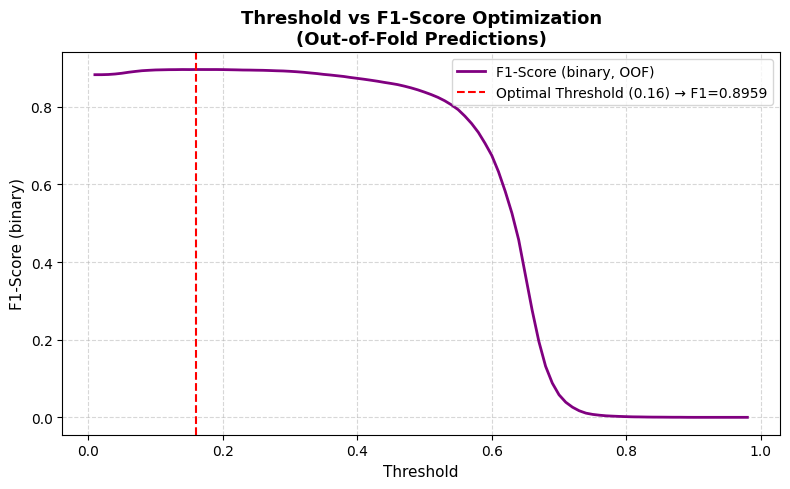

In [ ]:
##  PLOT: THRESHOLD vs F1-SCORE (OOF)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, label="F1-Score (binary, OOF)", color="purple", lw=2)
plt.axvline(
    final_threshold,
    color="red",
    linestyle="--",
    label=f"Optimal Threshold ({final_threshold:.2f}) → F1={best_f1:.4f}"
)
plt.title("Threshold vs F1-Score Optimization\n(Out-of-Fold Predictions)", fontsize=13, fontweight="bold")
plt.xlabel("Threshold", fontsize=11)
plt.ylabel("F1-Score (binary)", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("threshold_f1_optimization.png", dpi=150, bbox_inches="tight")
plt.show()


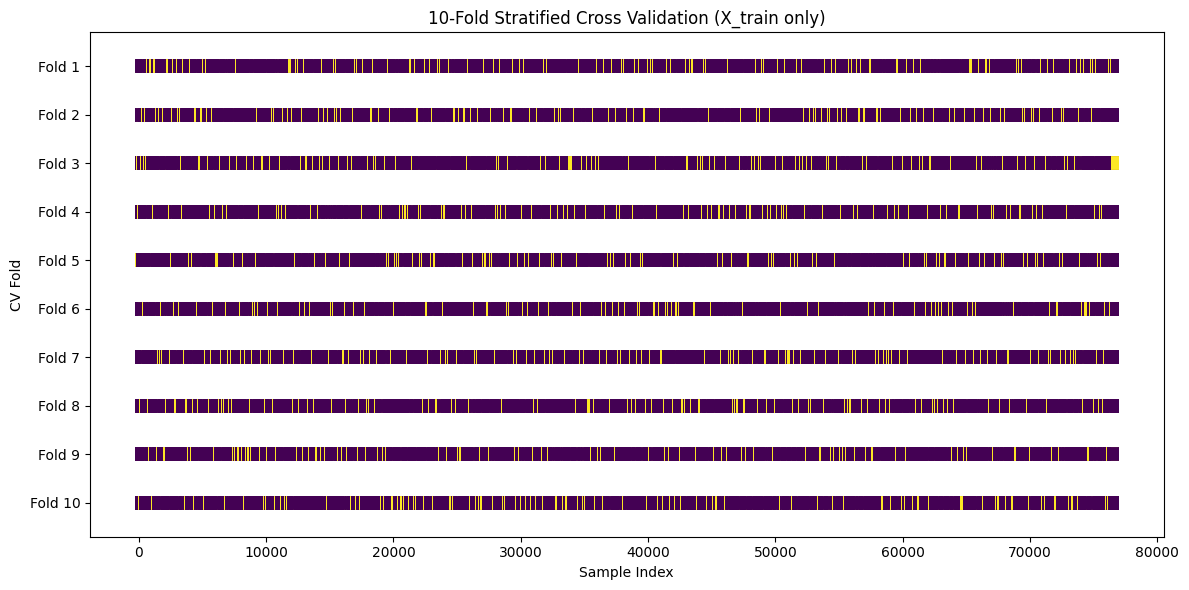

In [ ]:
##  VISUALISASI CROSS VALIDATION SPLITS

def plot_cv_indices(cv, X, y, ax, n_splits):
    """Visualisasi train/val split untuk setiap fold CV. Hanya menggunakan X_train dan y_train — test set tidak tersentuh."""
    for ii, (tr, val) in enumerate(cv.split(X, y)):
        indices = np.array([np.nan] * len(X))
        indices[val] = 1
        indices[tr]  = 0
        ax.scatter(
            range(len(indices)),
            [ii + 0.5] * len(indices),
            c=indices,
            marker="_",
            lw=10
        )
    ax.set(
        yticks=np.arange(n_splits) + 0.5,
        yticklabels=[f"Fold {i+1}" for i in range(n_splits)],
        xlabel="Sample Index",
        ylabel="CV Fold",
        title="10-Fold Stratified Cross Validation (X_train only)"
    )
    ax.set_ylim([n_splits + 0.2, -0.2])


##  EKSEKUSI hanya X_train & y_train, test set TIDAK digunakan

fig, ax = plt.subplots(figsize=(12, 6))
plot_cv_indices(skf, X_train, y_train, ax, N_FOLDS)
plt.tight_layout()
plt.show()


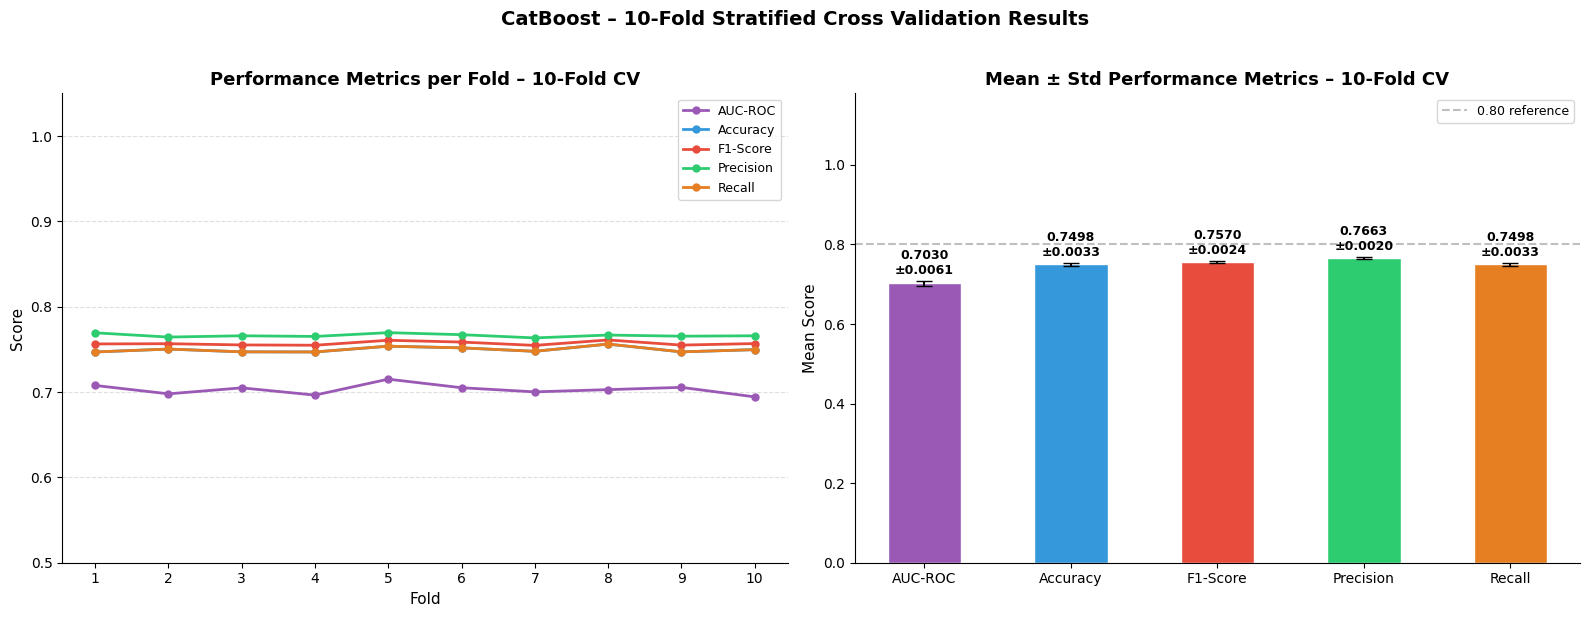


Cross Validation Summary Table:
 fold      auc  accuracy  f1_score  precision   recall
    1 0.707703  0.746968  0.756338   0.769388 0.746968
    2 0.697877  0.750359  0.756625   0.764413 0.750359
    3 0.704909  0.747098  0.755198   0.765915 0.747098
    4 0.696391  0.746968  0.754835   0.765146 0.746968
    5 0.715077  0.753718  0.760655   0.769582 0.753718
    6 0.705046  0.751761  0.758556   0.767203 0.751761
    7 0.700193  0.747717  0.754645   0.763414 0.747717
    8 0.702802  0.756196  0.761022   0.766768 0.756196
    9 0.705475  0.747065  0.755001   0.765427 0.747065
   10 0.694370  0.749674  0.756791   0.765914 0.749674


In [ ]:
##  Visualisasi Hasil 10-Fold Cross Validation

metrics_to_plot = [
    'auc', 'accuracy', 'f1_score', 'precision', 'recall' # All metrics
]

metric_labels = [
    'AUC-ROC', 'Accuracy', 'F1-Score', 'Precision', 'Recall' # All metric labels
]

metric_colors = [
    '#9B59B6', # AUC
    '#3498DB', # Accuracy
    '#E74C3C', # F1-Score
    '#2ECC71', # Precision
    '#E67E22'  # Recall
]

##  CREATE FIGURE

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)

##  PLOT 1 — METRIC PER FOLD

ax1 = axes[0]

for metric, label, color in zip(
    metrics_to_plot,
    metric_labels,
    metric_colors
):

    ax1.plot(
        cv_df['fold'],
        cv_df[metric],
        marker='o',
        label=label,
        color=color,
        linewidth=2,
        markersize=5
    )

ax1.set_xticks(cv_df['fold'])

ax1.set_xlabel(
    'Fold',
    fontsize=11
)

ax1.set_ylabel(
    'Score',
    fontsize=11
)

ax1.set_ylim(0.5, 1.05)

ax1.set_title(
    'Performance Metrics per Fold – 10-Fold CV',
    fontsize=13,
    fontweight='bold'
)

ax1.legend(fontsize=9)

ax1.grid(
    axis='y',
    linestyle='--',
    alpha=0.4
)

ax1.spines[['top', 'right']].set_visible(False)


##  PLOT 2 — MEAN ± STD
ax2 = axes[1]

means = [
    cv_df[m].mean()
    for m in metrics_to_plot
]

stds = [
    cv_df[m].std()
    for m in metrics_to_plot
]

bars = ax2.bar(
    metric_labels,
    means,
    color=metric_colors,
    yerr=stds,
    capsize=6,
    width=0.5,
    edgecolor='white'
)


##  VALUE LABELS
for bar, mean, std in zip(
    bars,
    means,
    stds
):

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 0.01,
        f"{mean:.4f}\n±{std:.4f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )


##  AXIS SETTINGS
ax2.set_ylim(0, 1.18)

ax2.axhline(
    y=0.8,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label='0.80 reference'
)

ax2.set_ylabel(
    'Mean Score',
    fontsize=11
)

ax2.set_title(
    'Mean ± Std Performance Metrics – 10-Fold CV',
    fontsize=13,
    fontweight='bold'
)

ax2.legend(fontsize=9)

ax2.spines[['top', 'right']].set_visible(False)

## FINAL DISPLAY
plt.suptitle(
    'CatBoost – 10-Fold Stratified Cross Validation Results',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()

plt.savefig(
    'cv_results.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


##  SUMMARY TABLE

print("\nCross Validation Summary Table:")

print(
    cv_df.to_string(index=False)
)


## Training CatBoost Classifier

### Keunggulan CatBoost untuk kasus ini:
### 1. Menerima string kategorikal langsung — tidak perlu encoding manual
### 2. Menggunakan bobot dinamis otomatis
### 3. `early_stopping_rounds` mencegah overfitting tanpa perlu Grid Search / CV terpisah

In [ ]:
##  HITUNG RATA-RATA BEST ITERATION DARI CV
average_best_iteration = int(np.mean(best_iterations))
print(f"Average best iteration from CV : {average_best_iteration}")


##  TRAINING FINAL MODEL PADA SELURUH X_TRAIN
#memasukkan 100% data X_train dan y_train secara utuh ke dalam objek Pool milik CatBoost
full_train_pool = Pool(
    X_train,
    y_train,
    cat_features=cat_cols
)

test_pool = Pool(
    X_test,
    cat_features=cat_cols
)

cb_model_final = CatBoostClassifier(
    iterations=average_best_iteration,
    learning_rate=0.03,
    depth=8,
    eval_metric="AUC",
    auto_class_weights="Balanced",
    l2_leaf_reg=5,
    random_seed=42,
    task_type="CPU"
)

# verbose=200 agar progress tetap terlihat tapi tidak terlalu ramai
cb_model_final.fit(
    full_train_pool,
    verbose=200
)

print("\nFinal CatBoost model berhasil dilatih pada seluruh X_train.")


Average best iteration from CV : 315
0:	total: 71.8ms	remaining: 22.6s
200:	total: 24.9s	remaining: 14.1s
314:	total: 40.5s	remaining: 0us

Final CatBoost model berhasil dilatih pada seluruh X_train.


## Threshold Tuning untuk Maksimalkan Akurasi

### Iterasi threshold 0.10 → 0.95 untuk menemukan titik optimal.

MODEL FINAL


In [ ]:
##  FINAL TEST PREDICTION
proba_test = cb_model_final.predict_proba(test_pool)[:, 1]

preds_final = (
    proba_test >= final_threshold
).astype(int)


##  FINAL METRICS
accuracy = accuracy_score(
    y_test,
    preds_final
)

auc = roc_auc_score(
    y_test,
    proba_test
)

f1 = f1_score(
    y_test,
    preds_final,
    average='weighted'
)

precision = precision_score(
    y_test,
    preds_final,
    average='weighted'
)

recall = recall_score(
    y_test,
    preds_final,
    average='weighted'
)

##  OUTPUT
print("\n" + "="*60)
print("Final CatBoost Model Evaluation")
print("="*60)

print(f"Final Threshold : {final_threshold:.2f}")
print(f"Accuracy        : {accuracy:.4f}")
print(f"F1-Score        : {f1:.4f}")
print(f"Precision       : {precision:.4f}")
print(f"Recall          : {recall:.4f}")
print(f"AUC-ROC         : {auc:.4f}")

print("-" * 60)

print(
    classification_report(
        y_test,
        preds_final
    )
)



Final CatBoost Model Evaluation
Final Threshold : 0.16
Accuracy        : 0.8198
F1-Score        : 0.7761
Precision       : 0.8103
Recall          : 0.8198
AUC-ROC         : 0.6979
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.76      0.21      0.33      4026
           1       0.82      0.98      0.90     15140

    accuracy                           0.82     19166
   macro avg       0.79      0.59      0.61     19166
weighted avg       0.81      0.82      0.78     19166



## Perbandingan CatBoost vs Random Forest

### Grafik berikut membandingkan performa CatBoost (model ini) dengan Random Forest (10-Fold CV + ADASYN). Data RF diambil dari hasil CV dan evaluasi test set yang sudah dijalankan sebelumnya.


In [ ]:
##  DATA PERBANDINGAN: CatBoost vs Random Forest

# Random Forest (hasil dari notebook RF, 10-Fold CV + ADASYN)
rf_test = {
    "Accuracy" : 0.7262,
    "F1-Score" : 0.7389,
    "Precision": 0.7577,
    "Recall"   : 0.7262,
    "AUC-ROC"  : 0.6843
}

rf_cv_folds = {
    "Accuracy" : [0.7200,0.7034,0.7149,0.7210,0.7291,0.7225,0.7198,0.7129,0.7188,0.7197],
    "F1-Score" : [0.7360,0.7218,0.7319,0.7348,0.7429,0.7363,0.7342,0.7284,0.7344,0.7345],
    "Precision": [0.7623,0.7528,0.7605,0.7556,0.7646,0.7572,0.7563,0.7525,0.7596,0.7578],
    "Recall"   : [0.7200,0.7034,0.7149,0.7210,0.7291,0.7225,0.7198,0.7129,0.7188,0.7197],
    "AUC-ROC"  : [0.6920,0.6852,0.6957,0.6813,0.6986,0.6928,0.6860,0.6860,0.6912,0.6886]
}

#CatBoost (model ini, dari cv_df dan evaluasi test set)
cb_test = {
    "Accuracy" : accuracy,
    "F1-Score" : f1,
    "Precision": precision,
    "Recall"   : recall,
    "AUC-ROC"  : auc
}

cb_cv_means = {
    "Accuracy" : cv_df["accuracy"].mean(),
    "F1-Score" : cv_df["f1_score"].mean(),
    "Precision": cv_df["precision"].mean(),
    "Recall"   : cv_df["recall"].mean(),
    "AUC-ROC"  : cv_df["auc"].mean()
}

cb_cv_stds = {
    "Accuracy" : cv_df["accuracy"].std(),
    "F1-Score" : cv_df["f1_score"].std(),
    "Precision": cv_df["precision"].std(),
    "Recall"   : cv_df["recall"].std(),
    "AUC-ROC"  : cv_df["auc"].std()
}

rf_cv_means = {k: np.mean(v) for k, v in rf_cv_folds.items()}
rf_cv_stds  = {k: np.std(v)  for k, v in rf_cv_folds.items()}

metrics_list = ["Accuracy", "F1-Score", "Precision", "Recall", "AUC-ROC"]

print("=" * 62)
print(f"{"Metric":<12} {"CatBoost Test":>15} {"RF Test":>12} {"Delta":>10}")
print("=" * 62)
for m in metrics_list:
    delta = cb_test[m] - rf_test[m]
    sign  = "▲" if delta > 0 else "▼" if delta < 0 else "─"
    print(f"{m:<12} {cb_test[m]:>15.4f} {rf_test[m]:>12.4f} {sign}{abs(delta):>8.4f}")
print("=" * 62)
print("  ▲ = CatBoost lebih baik  ▼ = Random Forest lebih baik")


Metric         CatBoost Test      RF Test      Delta
Accuracy              0.8198       0.7262 ▲  0.0936
F1-Score              0.7761       0.7389 ▲  0.0372
Precision             0.8103       0.7577 ▲  0.0526
Recall                0.8198       0.7262 ▲  0.0936
AUC-ROC               0.6979       0.6843 ▲  0.0136
  ▲ = CatBoost lebih baik  ▼ = Random Forest lebih baik


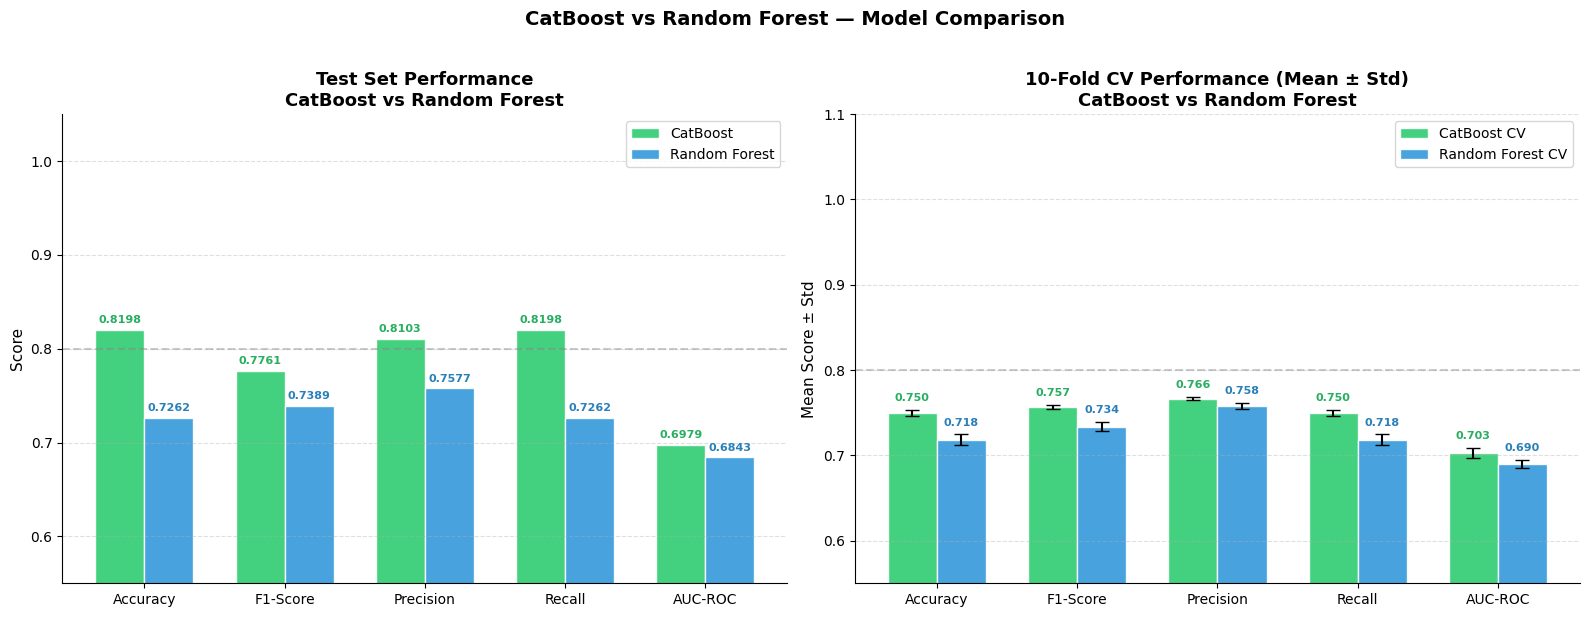

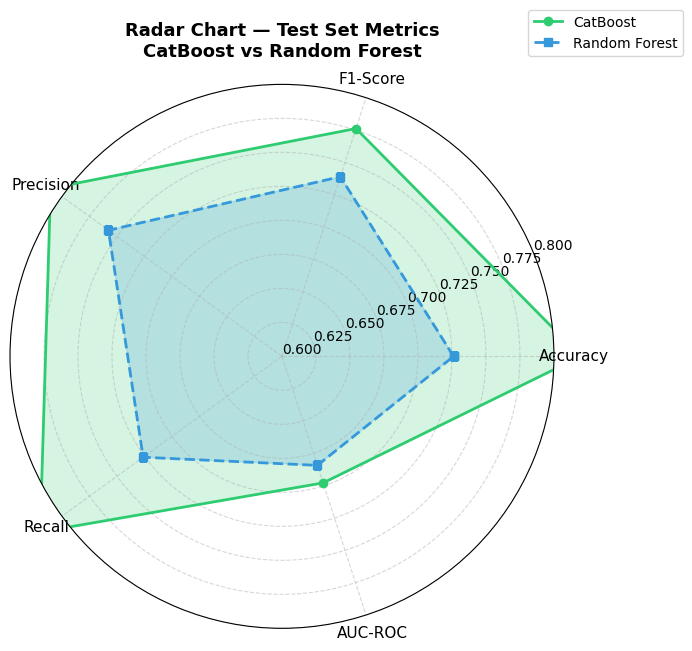

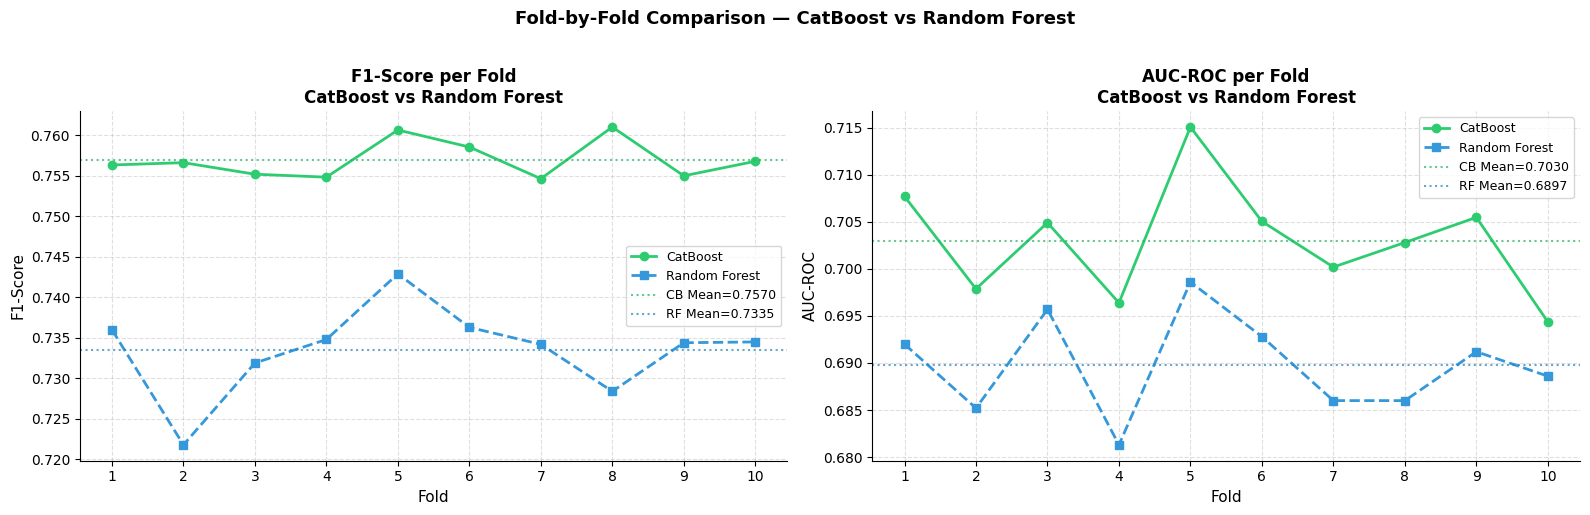

In [ ]:
##  PLOT 1: TEST SET — HEAD-TO-HEAD BAR CHART

x       = np.arange(len(metrics_list))
width   = 0.35
cb_vals = [cb_test[m]  for m in metrics_list]
rf_vals = [rf_test[m]  for m in metrics_list]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 kiri: Test Set comparison
ax1 = axes[0]
bars_cb = ax1.bar(x - width/2, cb_vals, width, label="CatBoost",      color="#2ECC71", edgecolor="white", alpha=0.9)
bars_rf = ax1.bar(x + width/2, rf_vals, width, label="Random Forest", color="#3498DB", edgecolor="white", alpha=0.9)

for bar, val in zip(bars_cb, cb_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#27AE60")
for bar, val in zip(bars_rf, rf_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#2980B9")

ax1.set_xticks(x)
ax1.set_xticklabels(metrics_list, fontsize=10)
ax1.set_ylim(0.55, 1.05)
ax1.set_ylabel("Score", fontsize=11)
ax1.set_title("Test Set Performance\nCatBoost vs Random Forest", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.axhline(y=0.8, color="gray", linestyle="--", alpha=0.4, label="0.80 ref")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.spines[["top", "right"]].set_visible(False)

# Plot 1 kanan: CV Mean ± Std comparison
ax2 = axes[1]
cb_means = [cb_cv_means[m] for m in metrics_list]
cb_stds  = [cb_cv_stds[m]  for m in metrics_list]
rf_means = [rf_cv_means[m] for m in metrics_list]
rf_stds  = [rf_cv_stds[m]  for m in metrics_list]

bars_cb2 = ax2.bar(x - width/2, cb_means, width, yerr=cb_stds, capsize=5,
                   label="CatBoost CV",      color="#2ECC71", edgecolor="white", alpha=0.9)
bars_rf2 = ax2.bar(x + width/2, rf_means, width, yerr=rf_stds, capsize=5,
                   label="Random Forest CV", color="#3498DB", edgecolor="white", alpha=0.9)

for bar, m, s in zip(bars_cb2, cb_means, cb_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.008,
             f"{m:.3f}", ha="center", va="bottom", fontsize=8, color="#27AE60", fontweight="bold")
for bar, m, s in zip(bars_rf2, rf_means, rf_stds):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.008,
             f"{m:.3f}", ha="center", va="bottom", fontsize=8, color="#2980B9", fontweight="bold")

ax2.set_xticks(x)
ax2.set_xticklabels(metrics_list, fontsize=10)
ax2.set_ylim(0.55, 1.10)
ax2.set_ylabel("Mean Score ± Std", fontsize=11)
ax2.set_title("10-Fold CV Performance (Mean ± Std)\nCatBoost vs Random Forest", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.axhline(y=0.8, color="gray", linestyle="--", alpha=0.4)
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.spines[["top", "right"]].set_visible(False)

plt.suptitle("CatBoost vs Random Forest — Model Comparison",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("model_comparison_cb_vs_rf.png", dpi=150, bbox_inches="tight")
plt.show()


##  PLOT 2: RADAR CHART (Spider Plot)

import matplotlib.patches as mpatches

labels   = metrics_list
N        = len(labels)
angles   = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles  += angles[:1]

cb_radar = [cb_test[m] for m in labels] + [cb_test[labels[0]]]
rf_radar = [rf_test[m] for m in labels] + [rf_test[labels[0]]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

ax.plot(angles, cb_radar, "o-", lw=2, color="#2ECC71", label="CatBoost")
ax.fill(angles, cb_radar, alpha=0.20, color="#2ECC71")

ax.plot(angles, rf_radar, "s--", lw=2, color="#3498DB", label="Random Forest")
ax.fill(angles, rf_radar, alpha=0.20, color="#3498DB")

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=11)
ax.set_ylim(0.60, 0.80)
ax.set_title("Radar Chart — Test Set Metrics\nCatBoost vs Random Forest",
             size=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.15), fontsize=10)
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("radar_comparison_cb_vs_rf.png", dpi=150, bbox_inches="tight")
plt.show()


##  PLOT 3: FOLD-BY-FOLD AUC COMPARISON (Line)

folds = list(range(1, 11))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, title in zip(
    axes,
    ["F1-Score", "AUC-ROC"],
    ["F1-Score per Fold", "AUC-ROC per Fold"]
):
    cb_vals_fold = cv_df["f1_score"].tolist() if metric == "F1-Score" else cv_df["auc"].tolist()
    rf_vals_fold = rf_cv_folds[metric]

    ax.plot(folds, cb_vals_fold, "o-", color="#2ECC71", lw=2, label="CatBoost")
    ax.plot(folds, rf_vals_fold, "s--", color="#3498DB", lw=2, label="Random Forest")

    ax.axhline(np.mean(cb_vals_fold), color="#27AE60", linestyle=":", alpha=0.7,
               label=f"CB Mean={np.mean(cb_vals_fold):.4f}")
    ax.axhline(np.mean(rf_vals_fold), color="#2980B9", linestyle=":", alpha=0.7,
               label=f"RF Mean={np.mean(rf_vals_fold):.4f}")

    ax.set_xticks(folds)
    ax.set_xlabel("Fold", fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(f"{title}\nCatBoost vs Random Forest", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Fold-by-Fold Comparison — CatBoost vs Random Forest",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("foldwise_comparison_cb_vs_rf.png", dpi=150, bbox_inches="tight")
plt.show()


## Confusion Matrix

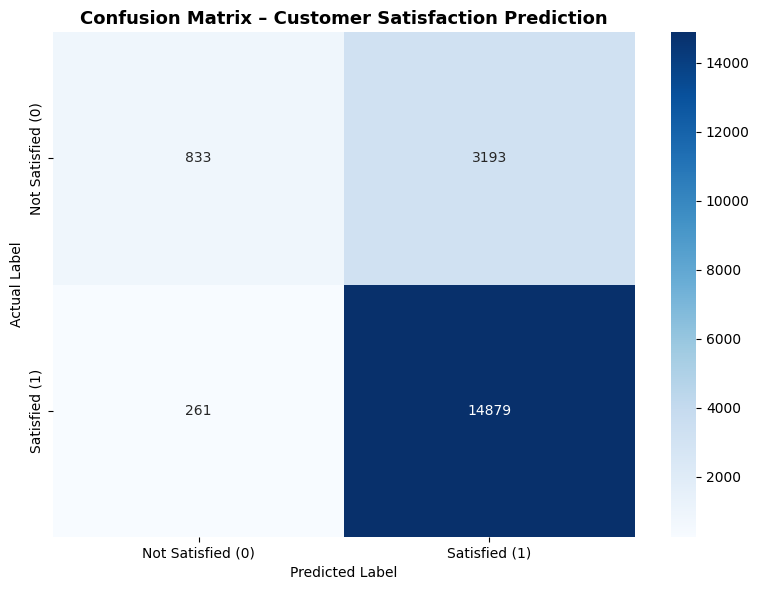

In [ ]:
cm = confusion_matrix(y_test, preds_final)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Satisfied (0)', 'Satisfied (1)'],
    yticklabels=['Not Satisfied (0)', 'Satisfied (1)']
)
plt.title('Confusion Matrix – Customer Satisfaction Prediction',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## Feature Importance

In [ ]:
fi = cb_model_final.get_feature_importance(full_train_pool)

fi_df = pd.DataFrame({
    "Feature"    : X_train.columns,
    "Importance" : fi
}).sort_values("Importance", ascending=False)

print("\nFeature Importances:")
print(fi_df.to_string(index=False))



Feature Importances:
                Feature  Importance
          delivery_time   31.113318
                is_late   27.787217
            total_items   16.073146
         customer_state    6.751591
          total_freight    5.384065
          customer_city    3.341439
       state_city_combo    3.005681
         price_per_item    2.395119
        total_price_log    2.233975
total_payment_value_log    1.914449


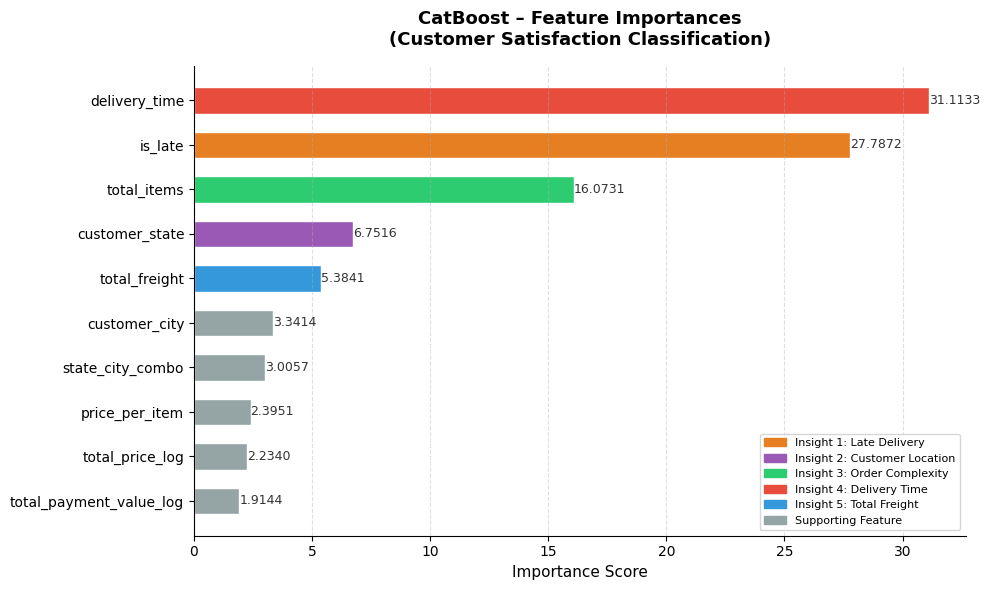

In [ ]:
mapping_dict = {
    "is_late"           : "Insight 1: Late Delivery",
    "customer_state"    : "Insight 2: Customer Location",
    "total_items"       : "Insight 3: Order Complexity",
    "delivery_time"     : "Insight 4: Delivery Time",
    "total_freight"     : "Insight 5: Total Freight",
}

COLOR_MAP = {
    "Insight 1: Late Delivery"     : "#E67E22",
    "Insight 2: Customer Location" : "#9B59B6",
    "Insight 3: Order Complexity"  : "#2ECC71",
    "Insight 4: Delivery Time"     : "#E74C3C",
    "Insight 5: Total Freight"     : "#3498DB",
    "Supporting Feature"           : "#95A5A6",
}

fi_df["Insight"] = fi_df["Feature"].map(mapping_dict).fillna("Supporting Feature")
fi_df = fi_df.sort_values("Importance", ascending=False)
colors = fi_df["Insight"].map(COLOR_MAP)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(fi_df["Feature"], fi_df["Importance"],
               color=colors, edgecolor="white", height=0.6)

for bar, val in zip(bars, fi_df["Importance"]):
    ax.text(
        bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va="center", ha="left", fontsize=9, color="#333333"
    )

legend_patches = [
    mpatches.Patch(color=COLOR_MAP[k], label=k)
    for k in [
        "Insight 1: Late Delivery",
        "Insight 2: Customer Location",
        "Insight 3: Order Complexity",
        "Insight 4: Delivery Time",
        "Insight 5: Total Freight",
        "Supporting Feature",
    ]
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.8)
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title(
    "CatBoost – Feature Importances\n(Customer Satisfaction Classification)",
    fontsize=13, fontweight="bold", pad=15
)
ax.invert_yaxis()
ax.grid(axis="x", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Visualisasi Metrics Evaluasi

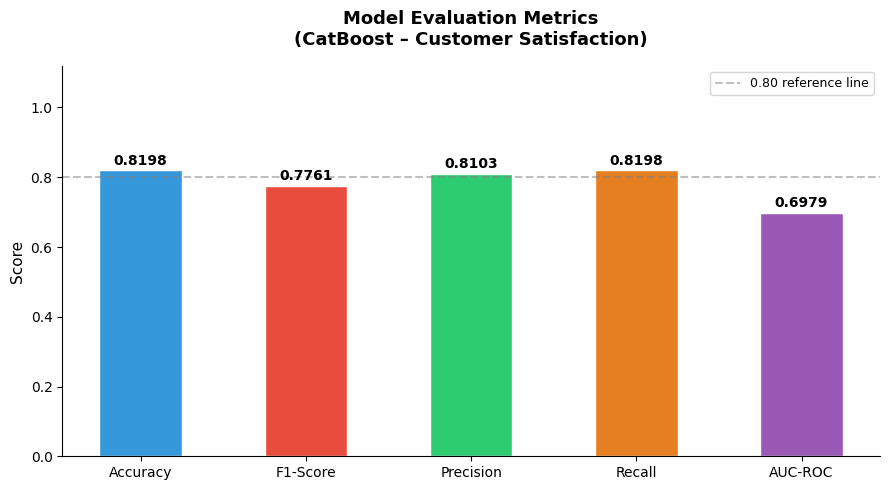

In [ ]:
metrics       = ["Accuracy", "F1-Score", "Precision", "Recall", "AUC-ROC"]
metric_vals   = [accuracy, f1, precision, recall, auc]
metric_colors = ["#3498DB", "#E74C3C", "#2ECC71", "#E67E22", "#9B59B6"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics, metric_vals, color=metric_colors, width=0.5, edgecolor="white")

for bar, val in zip(bars, metric_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
        f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylim(0, 1.12)
ax.axhline(y=0.8, color="gray", linestyle="--", alpha=0.5, label="0.80 reference line")
ax.set_ylabel("Score", fontsize=11)
ax.set_title(
    "Model Evaluation Metrics\n(CatBoost – Customer Satisfaction)",
    fontsize=13, fontweight="bold", pad=15
)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("model_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

TOP FEATURE

In [ ]:
print(
    fi_df[['Feature', 'Importance']]
    .head(10)
)

                   Feature  Importance
0            delivery_time   31.113318
1                  is_late   27.787217
4              total_items   16.073146
2           customer_state    6.751591
5            total_freight    5.384065
3            customer_city    3.341439
9         state_city_combo    3.005681
6           price_per_item    2.395119
8          total_price_log    2.233975
7  total_payment_value_log    1.914449


## Business Insights berdasarkan Feature Importance

In [ ]:
print("\nTop 10 Most Important Features:")
print(
    fi_df[['Feature', 'Importance']]
    .head(10)
    .to_string(index=False)
)

insights = [
    (
        "1. Keterlambatan Pengiriman – Faktor Prediktif Paling Kritis",
        "is_late",
        "Keterlambatan pengiriman sangat berkorelasi dengan ketidakpuasan pelanggan."
        "Ketika pengiriman aktual melebihi tanggal perkiraan, ada peningkatan signifikan dalam kemungkinan ulasan negatif.",
        "Tingkatkan kepatuhan SLA dan perbaiki algoritma estimasi pengiriman.",
    ),

    (
        "2. Lokasi Pelanggan – Variasi Kinerja Geografis",
        "customer_state",
        "Pola kepuasan pelanggan bervariasi di berbagai wilayah, menunjukkan adanya korelasi antara lokasi dan efisiensi logistik."
        "Hal ini dapat mengindikasikan perbedaan kinerja operasional antar negara bagian.",
        "Perkuat jaringan distribusi dan berkolaborasi dengan penyedia pengiriman jarak terakhir lokal"
        "di wilayah yang menunjukkan tingkat kepuasan lebih rendah."
    ),

    (
        "3. Kompleksitas Pesanan – Penanganan Banyak Barang" ,
        "total_items",
        "Pesanan yang berisi banyak barang menunjukkan korelasi yang lebih tinggi dengan ketidakpuasan pelanggan."
        "Hal ini dapat disebabkan oleh waktu konsolidasi yang lebih lama dan peningkatan risiko kesalahan pemenuhan pesanan.",
        "Optimalkan proses pengambilan dan pengemasan gudang secara khusus untuk pengiriman banyak barang."
    ),

    (
        "4. Waktu Pengiriman – Pengaruh Kecepatan Pengiriman",
        "delivery_time",
        "Meskipun pesanan dikirim dalam jangka waktu perkiraan, durasi pengiriman keseluruhan yang lebih lama berkorelasi dengan skor kepuasan pelanggan yang lebih rendah.",
        "Optimalkan alur pengiriman untuk mengurangi waktu transit rata-rata dari awal hingga akhir, sehingga meningkatkan kecepatan pengiriman yang dirasakan.",
    ),

    (
        "5.Biaya Pengiriman – Sensitivitas Harga Logistik",
        "total_freight",
        "Biaya pengiriman tampaknya memberikan kontribusi yang lebih signifikan terhadap ketidakpuasan dibandingkan dengan beberapa fitur terkait harga lainnya."
        "Biaya pengiriman yang tinggi, terutama jika dikombinasikan dengan durasi pengiriman yang lebih lama, dapat memperparah frustrasi pelanggan.",
        "Evaluasi strategi penetapan harga pengiriman atau pertimbangkan untuk memberikan subsidi/promosi pengiriman"
        "untuk wilayah yang diidentifikasi memiliki biaya logistik tinggi."
    ),
]


# DISPLAY INSIGHTS
for title, feat, insight_text, biz_meaning in insights:

    imp_val = fi_df.loc[
        fi_df["Feature"] == feat,
        "Importance"
    ].values

    imp_str = (
        f"{imp_val[0]:.4f}"
        if len(imp_val) > 0
        else "N/A"
    )

    print(f"\n{title}")
    print(f"     Feature Importance : {imp_str}")
    print(f"     Insight            : {insight_text}")
    print(f"     Business Action    : {biz_meaning}")


Top 10 Most Important Features:
                Feature  Importance
          delivery_time   31.113318
                is_late   27.787217
            total_items   16.073146
         customer_state    6.751591
          total_freight    5.384065
          customer_city    3.341439
       state_city_combo    3.005681
         price_per_item    2.395119
        total_price_log    2.233975
total_payment_value_log    1.914449

1. Keterlambatan Pengiriman – Faktor Prediktif Paling Kritis
     Feature Importance : 27.7872
     Insight            : Keterlambatan pengiriman sangat berkorelasi dengan ketidakpuasan pelanggan.Ketika pengiriman aktual melebihi tanggal perkiraan, ada peningkatan signifikan dalam kemungkinan ulasan negatif.
     Business Action    : Tingkatkan kepatuhan SLA dan perbaiki algoritma estimasi pengiriman.

2. Lokasi Pelanggan – Variasi Kinerja Geografis
     Feature Importance : 6.7516
     Insight            : Pola kepuasan pelanggan bervariasi di berbagai wilayah, m

Visualisasi Overlap Data

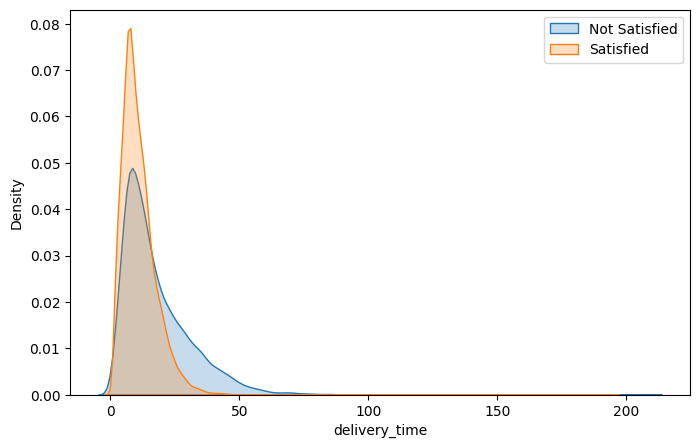

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    pdf[pdf['is_satisfied']==0]['delivery_time'],
    label='Not Satisfied',
    fill=True
)

sns.kdeplot(
    pdf[pdf['is_satisfied']==1]['delivery_time'],
    label='Satisfied',
    fill=True
)

plt.legend()
plt.show()

# Interpretasi Model

Model klasifikasi **CatBoost** menunjukkan bahwa kinerja terkait logistik — khususnya **Keterlambatan Pengiriman** dan **Waktu Pengiriman** — adalah pendorong utama kepuasan pelanggan. Ini menegaskan bahwa keandalan operasional dan pemenuhan janji pengiriman jauh lebih penting daripada sekadar harga dalam membentuk pengalaman pelanggan.

**Keputusan teknis utama:**
- **`class_weights'** otomatis menggunakan fitur Balanced dari model Catboost
- **`predict_proba(test_pool)`** menggunakan Pool yang sudah mencakup informasi `cat_features`, bukan `X_test` mentah, sehingga konsisten dengan cara model dilatih dan aman dari kesalahan tipe data.
- **Iterasi yang Dioptimalkan**: Model akhir dilatih menggunakan `average_best_iteration` yang diperoleh dari validasi silang. Pendekatan ini mencegah overfitting tanpa memerlukan `early_stopping_rounds` selama pelatihan akhir pada dataset lengkap.

**Skor F1** ditekankan sebagai metrik utama karena distribusi kelas yang tidak seimbang (79% vs. 21%). **AUC–ROC** mengkonfirmasi kemampuan diskriminatif keseluruhan model.

## Save Data to Parquet

In [ ]:

output_path_single = "/content/df_master_processed_single.parquet"

!rm -rf /content/df_master_processed.parquet

pdf.to_parquet(output_path_single, index=False)

print(f"Final processed data saved to {output_path_single}")

Final processed data saved to /content/df_master_processed_single.parquet


## Download Parquet File

In [ ]:
from google.colab import files


file_to_download = "/content/df_master_processed_single.parquet"

files.download(file_to_download)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
parquet_path = "/content/df_master_processed_single.parquet"

isi = spark.read.parquet(parquet_path)
isi.show(5, truncate=False)


+--------------------------------+--------------------------------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+------------------+-----------------------+-----------------+----------------+
|order_id                        |customer_id                     |delivery_time|is_late|customer_state|customer_city|is_satisfied|total_payment_value|total_items|total_price|total_freight|price_per_item    |total_payment_value_log|total_price_log  |state_city_combo|
+--------------------------------+--------------------------------+-------------+-------+--------------+-------------+------------+-------------------+-----------+-----------+-------------+------------------+-----------------------+-----------------+----------------+
|615ae1b88a25a4ac47fbf55c9c847b6e|25daddfce277eafad87c4d28d71d8229|10           |0      |PR            |londrina     |0           |84.64              |1          |64.99      |19.65        |64.9899